# Questão 2

### 2. a

Pela definição, $L_X(p) = (p(x_1), p(x_2),..., p(x_m)) \in \mathbb{R}^m$. Chame $b = L_X(p)$. 

$R_{X,d}(b)$ é o polinômio $q \in P_d$ que minimiza: $$||L_X(q) - b||_{2}^2 = \sum_{i=1}^m (q(x_i)-b_i)^2$$

Substituindo $q=p$: $$\sum_{i=1}^m (p(x_i) - b)^2 = \sum_{i=1}^m (p(x_i) - p(x_i))^2 = 0$$

O menor valor possível de uma soma de quadrados é 0, portanto, p é a solução do problema de mínimos quadrados.

Como $R_{X,d}(L_X(p)) = p$ concluímos que $$R_{X,d} \circ L_X = Id_{P_d}$$

### 2. b

Seja $v_1 = R_{X,d}(b_1)$ e $v_2 = R_{X,d}(b_2) \Rightarrow V^*Vv_1 = V^*b_1$ e $V^*Vv_2 = V^*b_2$.

$R_{X,d}(\alpha b_1 + \beta b_2) = v' \Leftrightarrow V^*Vv' = V^*(\alpha b_1 + \beta b_2)$

Como $V$ tem posto cheio, temos que $V^*V$ é invertível, o que faz com que a solução seja única.

Se $v' = \alpha v_1 + \beta v_2 \Rightarrow V^*Vv' = V^*V(\alpha v_1 + \beta v_2) = \alpha V^*Vv_1 + \beta V^*Vv_2 = V^*(\alpha b_1 + \beta b_2)$

Portanto concluímos que $R_{X,d}(\alpha b_1 + \beta b_2) = \alpha R_{X,d}(b_1) + \beta R_{X,d}(b_2)$

Logo $R_{X,d}$ é uma transformação linear.

### 2. c

Para calcular a matriz de $R_{X,d}:\mathbb{R}^m \rightarrow P_d$, usamos a base canônica ${e_1, e_2,..., e_m}$ de $\mathbb{R}^m$ e a base canônica ${1, x,..., x^d}$ de $P_d$. A j-ésima coluna da matriz é obtida calculando $R_{X,d}(e_j)$, ou seja, o polinômio $p \in P_d$ que minimiza $||L_X(p) - e_j||_{2}^2$. Isso é exatamente o polinômio que vale 1 no ponto $x_j$ e 0 em todos os outros pontos de X, logo, $p(x_i) = \delta_{i,j}$. Esse é exatamente o polinômio interpolador de Lagrange.

Portanto, a matriz de $R_{X,d}$ é a matriz $(d+1)\times m$ cujas colunas são os coeficientes dos polinômios interpoladores de Lagrange $p_1,..., p_m$ escritos na base canônica. Se $p_j(x) = a_{0}^{(j)} + a_{1}^{(j)}x + ... + a_{d}^{(j)}x^d$, então: 
$$ [R_{X,d}] =
\begin{pmatrix}
a_0^{(1)} & a_0^{(2)} & \cdots & a_0^{(m)} \\
a_1^{(1)} & a_1^{(2)} & \cdots & a_1^{(m)} \\
\vdots    & \vdots    & \ddots & \vdots    \\
a_d^{(1)} & a_d^{(2)} & \cdots & a_d^{(m)}
\end{pmatrix} $$

De forma equivalente, como a matriz de $L_X$ na base canônica é a matriz de Vondermonde $V$ de tamanho $m \times (d+1)$, a solução de mínimos quadrados é dada pela pseudoinversa $[R_{X,d}] = (V^{T}V)^{-1}V^T$.

### 2. d

In [29]:
import numpy as np
import matplotlib.pyplot as plt

In [30]:
def canonic_Lx_test_fixing_m(m: int, ax=None) -> None:
    X = np.linspace(-1,1,m)
    x = np.linspace(2,m,m-1)
    y = []
    for d in range(1, m):
        V = np.vander(X, N=d+1, increasing=True)
        c = np.linalg.cond(V)
        y.append(c)
    ax.plot(x, y)
    ax.set_xlabel("d")
    ax.set_ylabel("cond")
    ax.set_yscale("log")


def canonic_Lx_test_fixing_d(d:int, max_m:int, ax=None) -> None:
    x = []
    y = []
    for m in range(d+1, max_m+1):
        X = np.linspace(-1,1,m)
        V = np.vander(X,N=d+1,increasing=True)
        c = np.linalg.cond(V)
        x.append(m)
        y.append(c)
    ax.plot(x, y)
    ax.set_xlabel("m")
    ax.set_ylabel("cond")
    ax.set_yscale("log")

def canonic_Rx_test_fixing_m(m: int, ax=None) -> None:
    X = np.linspace(-1,1,m)
    x = np.linspace(2,m,m-1)
    y = []
    for d in range(1, m):
        V = np.vander(X, N=d+1, increasing=True)
        V = np.linalg.pinv(V)
        c = np.linalg.cond(V)
        y.append(c)
    ax.plot(x, y)
    ax.set_xlabel("d")
    ax.set_ylabel("cond")
    ax.set_yscale("log")


def canonic_Rx_test_fixing_d(d:int, max_m:int, ax=None) -> None:
    x = []
    y = []
    for m in range(d+1, max_m+1):
        X = np.linspace(-1,1,m)
        V = np.vander(X,N=d+1,increasing=True)
        V = np.linalg.pinv(V)
        c = np.linalg.cond(V)
        x.append(m)
        y.append(c)
    ax.plot(x, y)
    ax.set_xlabel("m")
    ax.set_ylabel("cond")
    ax.set_ylabel("log")

Nessa questão vamos utilizar o conjunto de pontos $X$ = np.linspace[$-1,1,m$].

A escolha é bem natural por 2 motivos:

1)  A questão 3 já pede pra utilizar X = linspace[$-1,1,m$].

2) Manter os pontos no intervalo [$-1,1$] evita que as colunas de $x^d$ explodam, assim, o crescimento de $\kappa(V)$ reflete o a má condição da base canônica.

Text(0.5, 1.0, 'Rx fixando m')

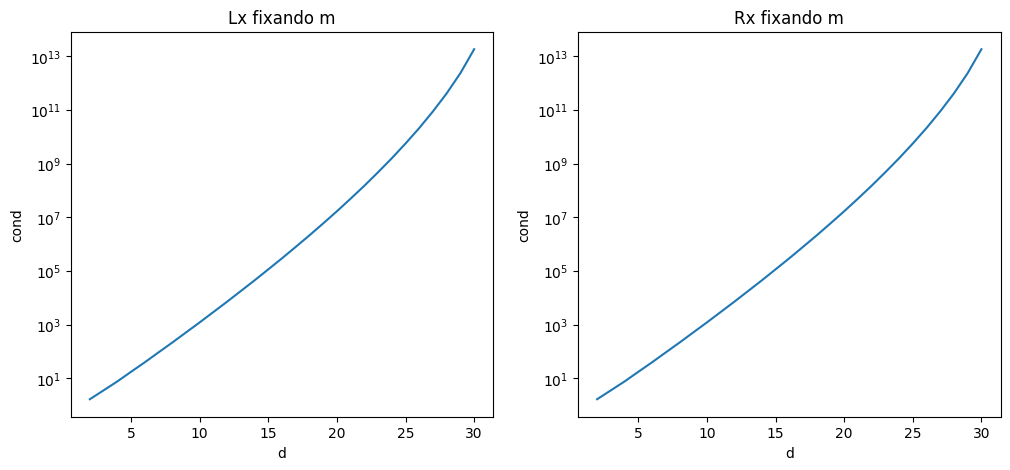

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

canonic_Lx_test_fixing_m(30, ax=ax1)
ax1.set_title("Lx fixando m")

canonic_Rx_test_fixing_m(30, ax=ax2)
ax2.set_title("Rx fixando m")

Text(0.5, 1.0, 'Rx fixando d')

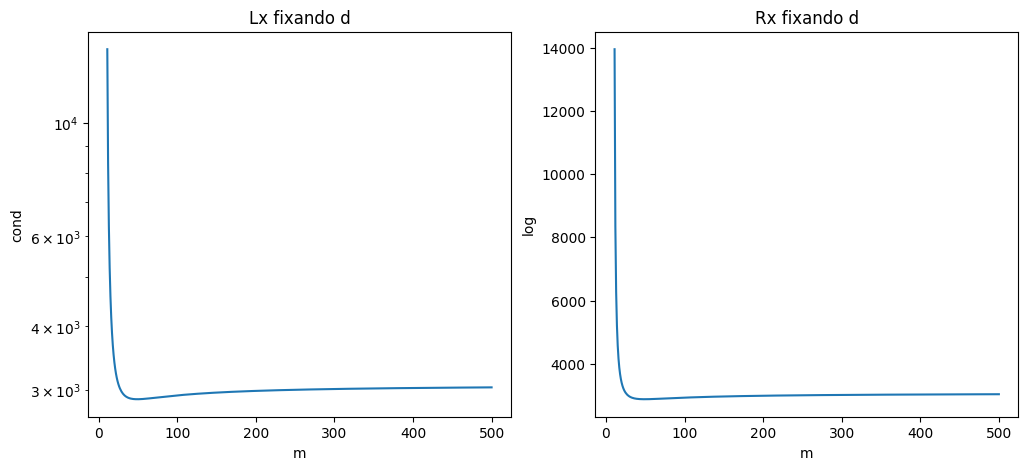

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

canonic_Lx_test_fixing_d(10, 500, ax=ax1)
ax1.set_title("Lx fixando d")

canonic_Rx_test_fixing_d(10, 500, ax=ax2)
ax2.set_title("Rx fixando d")

Como podemos ver, aumentar $d$ com $m$ fixo aumenta drasticamente o condicionamento da matriz, enquanto aumentar $m$ fixando $d$ estabiliza o condicionamento da matriz.

### 2. e

In [33]:
def lagrange_basis(X, d):
    m = len(X)
    indices = np.round(np.linspace(0, m-1, d+1)).astype(int)
    X = X[indices]
    basis = []

    for i in range(d+1):
        p = np.poly1d([1])

        for j in range(d+1):
            if j != i:
                p *= np.poly1d((1, - X[j])) / (X[i] - X[j])
        basis.append(p)

    return basis

def lagrange_L_X(X, d):
    m = len(X)
    basis = lagrange_basis(X, d)
    M = np.zeros((m, d+1))
    for j in range(d+1):
        for i in range(m):
            M[i,j] = basis[j](X[i])
    return M

def lagrange_R_Xd(X, d):
    Lx = lagrange_L_X(X, d)
    return np.linalg.pinv(Lx)

def lagrange_Lx_test_fixing_m(m: int, ax=None) -> None:
    X = np.linspace(-1,1,m)
    x = np.linspace(2,m,m-1)
    y = []
    for d in range(1, m):
        M = lagrange_L_X(X, d)
        c = np.linalg.cond(M)
        y.append(c)
    ax.plot(x, y)
    ax.set_xlabel("d")
    ax.set_ylabel("cond")
    ax.set_yscale("log")


def lagrange_Lx_test_fixing_d(d:int, max_m:int, ax=None) -> None:
    x = []
    y = []
    for m in range(d+1, max_m+1):
        X = np.linspace(-1,1,m)
        M = lagrange_L_X(X, d)
        c = np.linalg.cond(M)
        x.append(m)
        y.append(c)
    ax.plot(x, y)
    ax.set_xlabel("m")
    ax.set_ylabel("cond")

def lagrange_Rx_test_fixing_m(m: int, ax=None) -> None:
    X = np.linspace(-1,1,m)
    x = np.linspace(2,m,m-1)
    y = []
    for d in range(1, m):
        M = lagrange_R_Xd(X, d)
        c = np.linalg.cond(M)
        y.append(c)
    ax.plot(x, y)
    ax.set_xlabel("d")
    ax.set_ylabel("cond")
    ax.set_yscale("log")


def lagrange_Rx_test_fixing_d(d:int, max_m:int, ax=None) -> None:
    x = []
    y = []
    for m in range(d+1, max_m+1):
        X = np.linspace(-1,1,m)
        M = lagrange_R_Xd(X, d)
        c = np.linalg.cond(M)
        x.append(m)
        y.append(c)
    ax.plot(x, y)
    ax.set_xlabel("m")
    ax.set_ylabel("cond")

Text(0.5, 1.0, 'Rx fixando m')

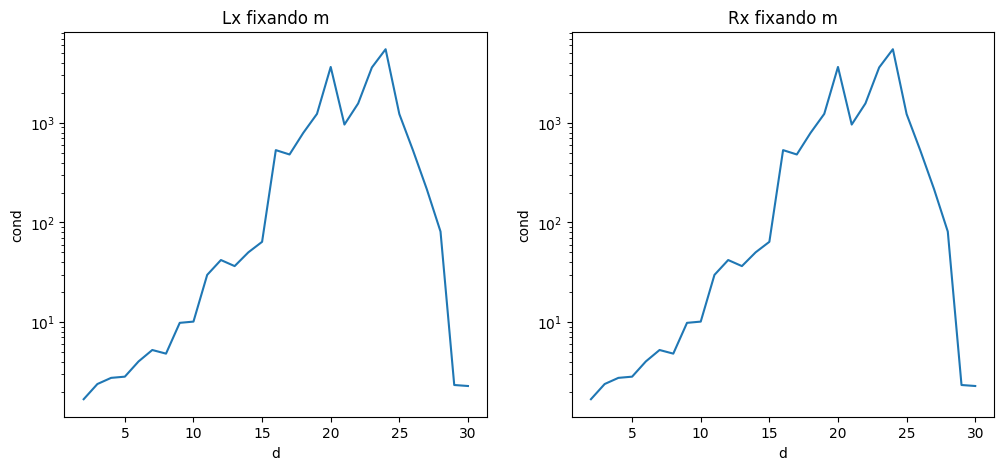

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

lagrange_Lx_test_fixing_m(30, ax=ax1)
ax1.set_title("Lx fixando m")

lagrange_Rx_test_fixing_m(30, ax=ax2)
ax2.set_title("Rx fixando m")

Text(0.5, 1.0, 'Rx fixando d')

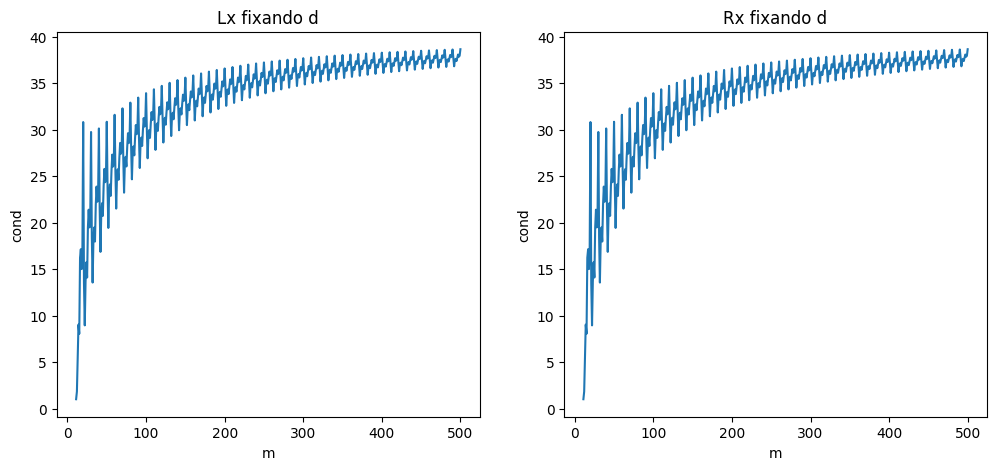

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

lagrange_Lx_test_fixing_d(10, 500, ax=ax1)
ax1.set_title("Lx fixando d")

lagrange_Rx_test_fixing_d(10, 500, ax=ax2)
ax2.set_title("Rx fixando d")

Text(0.5, 1.0, 'Rx fixando m')

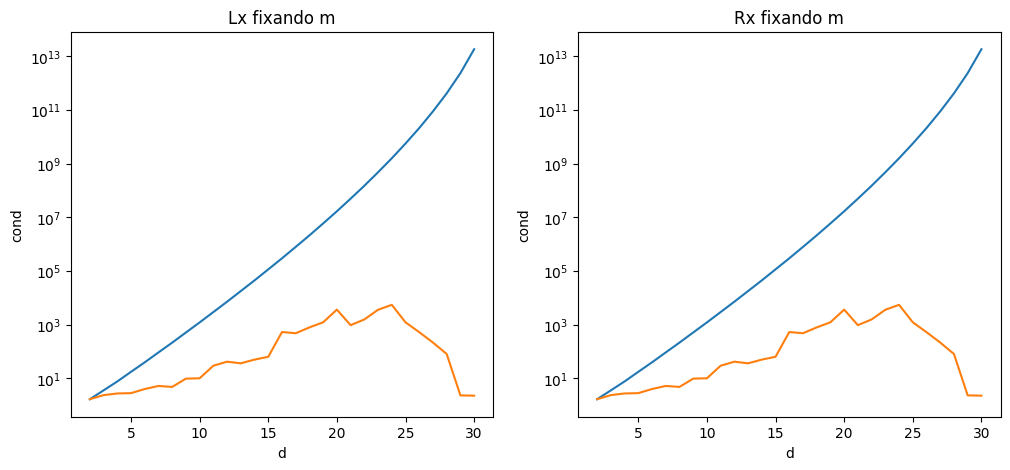

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

canonic_Lx_test_fixing_m(30, ax=ax1)
lagrange_Lx_test_fixing_m(30, ax=ax1)
ax1.set_title("Lx fixando m")

canonic_Rx_test_fixing_m(30, ax=ax2)
lagrange_Rx_test_fixing_m(30, ax=ax2)
ax2.set_title("Rx fixando m")

Text(0.5, 1.0, 'Rx fixando d')

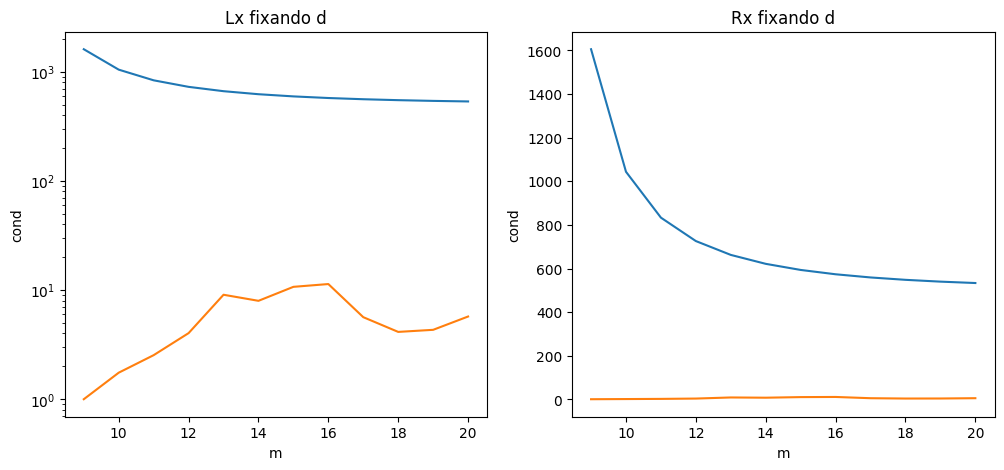

In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

canonic_Lx_test_fixing_d(8, 20, ax=ax1)
lagrange_Lx_test_fixing_d(8, 20, ax=ax1)
ax1.set_title("Lx fixando d")

canonic_Rx_test_fixing_d(8, 20, ax=ax2)
lagrange_Rx_test_fixing_d(8, 20, ax=ax2)
ax2.set_title("Rx fixando d")

### 2. f

Segue abaixo a tabela com o custo computacional de calcular as matrizes $L_X$ e $R_{X,d}$ nas bases canônica e de lagrange.

| Base     | $L_X$         | $R_{X,d}$ |
|----------|---------------|-----------|
| Canônica | $O(md)$       | $O(md^2)$ |
| Lagrange | $O(d^3 + md)$ | $O(md^2)$ |

Podemos reparar que o condicionamento de ambas as matrizes é muito melhor na base de lagrange

É fácil ver que $R_{X,d}$ é melhor na base de lagrange visto que a complexidade de caluclar na base de lagrange ou na canônica é a mesma, a dúvida é sobre usar $L_X$ na base canônica ou de Lagrange.

No entanto é fácil perceber que a matriz $L_X$ é muito melhor condicionada na base dos polinômios de lagrange.

Como podemos ver no gráfico fixando m, a matriz de $L_X$ na base de lagrange fica entre $1 - 10^3$ para $m = 30$ enquanto a canônica explode pra $10^{13}$, não só isso o condicionamento na base de lagrange cai pra $1$ quando $m=d+1$, o que é muito bom.

No gráfico fixando d também é fácil ver que o condicionamento da matriz na base de lagrange é muito melhor.

Portanto concluímos que o condicionamento incrivelmente melhor de $L_X$ na base de lagrange faz valer a pena o custo de calcular os polinômios.

É importante notar que essa melhora só acontece se escolhermos os polinômios para pontos igualmente espaçados em X.

Se simplesmente usarmos os $d+1$ primeiros pontos de X o condicionamento das matrizes na base de Lagrange fica muito pior que na base canônica.

# Questão 3

### 3. a

A imagem de $L_{Y} \circ R_{X,d}$ é o conjunto de todos os vetores da forma $L_Y(p)$ onde $p \in P_d$, ou seja, é a imagem de $L_Y$ restrita a $P_d$. 

Como $P_d$ tem dimensão $d+1$ e $L_Y$ é injetora em $P_d$ (pois $n \geq d + 1$), a imagem tem dimensão $d+1$. Portanto: $$rank(L_Y \circ R_{X,d}) = d+1$$

In [38]:
d = 3
m = 10
n = 8

X = np.linspace(-1, 1, m)
Y = np.linspace(-1, 1, n)

V_X = np.vander(X, d+1, increasing=True)  

R = np.linalg.pinv(V_X)  

V_Y = np.vander(Y, d+1, increasing=True)  

M = V_Y @ R

print(f"Posto de L_Y ∘ R_{{X,d}}: {np.linalg.matrix_rank(M)}")
print(f"d+1 = {d+1}")

Posto de L_Y ∘ R_{X,d}: 4
d+1 = 4


### 3. b

A composição $L_Y \circ R_{X,d} : \mathbb{R}^m \rightarrow \mathbb{R}^n$ tem domínio $\mathbb{R}^m$ e contradomínio $\mathbb{R}^n$. O espaço $P_d$ aparece apenas como espaço intermediário, e a escolha de base nele afeta as matrizes de $R_{X,d}$ e $L_Y$ separadamente. Porém, se $P$ é a matriz de mudança de base entre duas bases $B_1$ e $B_2$ de $P_d$, então: $$[L_Y]_{B_1} \cdot [R_{X,d}]_{B_1} = [L_Y]_{B_2}\cdot P \cdot P^{-1} \cdot [R_{X,d}]_{B_2} = [L_Y]_{B_2} \cdot [R_{X,d}]_{B_2}$$

As matrizes de mudança de base se cancelam, e o produto final é o mesmo independentemente da base escolhida. Isso faz sentido pois a composição é uma transformação linear de $\mathbb{R}^m$ em $\mathbb{R}^n$, e sua ação não depende de como representamos o espaço intermediário $P_d$.

### 3. c

Pela questão 2.a, se $b = L_X(q)$ para algum $q \in P_d$, então $R_{X,d}(b) = q$, e portanto $L_Y \circ R_{X,d}(b) = L_Y(q)$, ou seja, os valores exatos de $q$ nos pontos de $Y$.

Nesse sentido, a composta interpola: a partir dos valores de um polinômio de grau $d$ em $m$ pontos de $X$, recupera exatamente os seus valores em $n$ pontos de $Y$.

### 3. d

In [39]:
def lagrange_L_Y(X, Y, d):
    basis = lagrange_basis(X, d)  # constrói com pontos de X
    m = len(Y)
    M = np.zeros((m, d+1))
    for j in range(d+1):
        for i in range(m):
            M[i, j] = basis[j](Y[i])  # avalia em Y
    return M

Testaremos para $m \in [20,30], d \in [5,15], n = m-10$

In [40]:
def eigenvalues_printer(m,n,d):
    X = np.linspace(-1, 1, m)
    Y = np.linspace(-1, 1, n)

    V_X = np.vander(X, N=d+1, increasing=True)
    R_X = np.linalg.pinv(V_X)
    V_Y = np.vander(Y, N=d+1, increasing=True)
    composta_canonica = V_Y @ R_X

    L_X = lagrange_L_X(X, d)
    R_X_lag = np.linalg.pinv(L_X)
    L_Y = lagrange_L_Y(X, Y, d)
    composta_lagrange = L_Y @ R_X_lag

    print("Autovalores da base canônica:")
    print(np.linalg.svd(composta_canonica, compute_uv=False))
    print("")
    print("Autovalores da base de Lagrange:")
    print(np.linalg.svd(composta_lagrange, compute_uv=False))
    print("")
    print(f"Matrizes são iguais: {np.allclose(composta_canonica, composta_lagrange)}")
    print("_____________________________________________________________")

eigenvalues_printer(10,8,5)
eigenvalues_printer(20,10,8)
eigenvalues_printer(5,10,4)


Autovalores da base canônica:
[1.00133211e+00 9.94117132e-01 8.82922511e-01 8.81993320e-01
 8.61640173e-01 8.12225213e-01 1.76366757e-16 8.30895576e-17]

Autovalores da base de Lagrange:
[1.00133211e+00 9.94117132e-01 8.82922511e-01 8.81993320e-01
 8.61640173e-01 8.12225213e-01 8.10641780e-17 5.08537680e-17]

Matrizes são iguais: True
_____________________________________________________________
Autovalores da base canônica:
[9.99093981e-01 9.96697757e-01 7.25065329e-01 6.97732516e-01
 6.88248055e-01 6.88187998e-01 6.87656729e-01 4.69129171e-01
 2.90712787e-01 1.54608289e-16]

Autovalores da base de Lagrange:
[9.99093981e-01 9.96697757e-01 7.25065329e-01 6.97732516e-01
 6.88248055e-01 6.88187998e-01 6.87656729e-01 4.69129171e-01
 2.90712787e-01 1.19281509e-16]

Matrizes são iguais: True
_____________________________________________________________
Autovalores da base canônica:
[1.99179423 1.57843252 1.49682774 1.03988312 1.00458936]

Autovalores da base de Lagrange:
[1.99179423 1.57843

### 3. e

A composição $L_Y \circ R_{X,d}:\mathbb{R}^m \rightarrow \mathbb{R}^n$ pode ser entendida como: dado $b \in \mathbb{R}^m$, encontra o polinômio $p \in P_d$ que melhor se ajusta aos dados e avalia $p$ nos $n$ pontos de $Y$. O condicionamento dessa composição mede o quanto erros em $b$ se amplificam no resultado.

Quando $n \rightarrow \infty$ com $d$ fixo, estamos apenas avaliando o mesmo polinômio $p \in P_d$ em mais pontos. Como $p$ é determinado apenas por $m$ e $d$, adicionar mais pontos de avaliação não altera o polinômio encontrado. O condicionamento não é prejudicado com $n \rightarrow \infty$.

Quando $d$ também cresce, a situação muda, polinômios de grau alto são numericamente instáveis, e o condicionamento explode.  

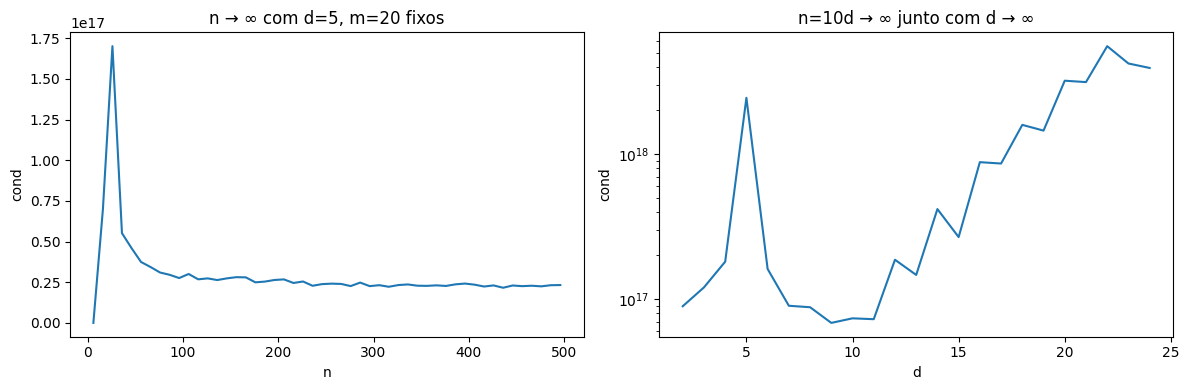

In [ ]:
def composicao(m, n, d):
    X = np.linspace(-1, 1, m)
    Y = np.linspace(-1, 1, n)
    Ly = lagrange_L_X(Y, d)
    Rx = lagrange_R_Xd(X, d)
    return Ly @ Rx

d = 5
m = 20
ns = range(d+1, 500, 10)
conds = [np.linalg.cond(composicao(m, n, d)) for n in ns]
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(list(ns), conds)
plt.xlabel("n")
plt.ylabel("cond")
plt.title(f"n → ∞ com d={d}, m={m} fixos")


m = 50
ds = range(2, 25)
conds2 = [np.linalg.cond(composicao(m, 10*d, d)) for d in ds]
plt.subplot(1, 2, 2)
plt.plot(list(ds), conds2)
plt.xlabel("d")
plt.ylabel("cond")
plt.title("n=10d → ∞ junto com d → ∞")
plt.yscale("log")
plt.tight_layout()
plt.savefig("cond_composicao.png", dpi=150)
plt.show()